In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
import os

# Define the root directory of your dataset in Kaggle
DATA_ROOT = 'classification_dataset'

# Establish main directory paths for training and validation splits
train_dir = os.path.join(DATA_ROOT, 'train')
val_dir = os.path.join(DATA_ROOT, 'valid')

In [3]:
import torchvision.models as models
from torchvision import transforms

# Load the official pre-trained weights to extract their required transformation pipeline
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
base_transforms = weights.transforms()

# Define the training transforms (Injecting basic augmentations for regular transfer learning)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip the image horizontally (50% chance)
    transforms.RandomVerticalFlip(p=0.5),   # Randomly flip the image vertically (50% chance) for orientation invariance
    base_transforms # Automatically applies resizing (224x224), cropping, and ImageNet normalization
])

# Define the validation transforms (Pure preprocessing without augmentations)
val_transforms = base_transforms

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets

# 1. Paths to your Roboflow splits (Assumes the DATA_ROOT cell from earlier was run)
# 'train_dir' and 'val_dir' were defined as: os.path.join(DATA_ROOT, 'train') etc.
print(f"Checking paths...\nTrain: {train_dir}\nValidation: {val_dir}")

# 2. Instantiate the Datasets using PyTorch's native ImageFolder wrapper
# This automatically scans the folders and assigns integer labels (0, 1, 2) based on class names
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transforms)

# 3. Create DataLoaders for efficient batch feeding during training
# batch_size=32 is highly stable and prevents Out-Of-Memory (OOM) errors on standard GPUs
# pin_memory=True speeds up the data transfer from CPU to GPU
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# 4. Print validation statistics to make sure everything parsed correctly
print("\n--- Dataset Summary ---")
print(f"Total training images: {len(train_dataset)}")
print(f"Total validation images: {len(val_dataset)}")
print(f"Detected classes (mapped to 0, 1, 2): {train_dataset.classes}")

Checking paths...
Train: classification_dataset\train
Validation: classification_dataset\valid

--- Dataset Summary ---
Total training images: 2649
Total validation images: 1618
Detected classes (mapped to 0, 1, 2): ['background', 'fish', 'partial_fish']


In [5]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

# 1. Check for GPU acceleration (Crucial for deep learning tasks)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load the official ConvNeXt Tiny architecture with pretrained ImageNet weights
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
model = models.convnext_tiny(weights=weights)


# 3. Freeze all backbone layers to prevent their weights from changing during Phase 1
for param in model.parameters():
    param.requires_grad = False

# 4. Modify the classification head for 3 target classes
# In torchvision's ConvNeXt, the classifier is a Sequence where index 2 is the Linear layer
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 3)

# 5. Move the model to the designated device (GPU or CPU)
model = model.to(device)

# 6. Define CrossEntropyLoss for multiclass classification
criterion = nn.CrossEntropyLoss()

# 7. Configure the optimizer to track ONLY the unfrozen parameters (the new classifier head)
# We can use a relatively higher learning rate (1e-3) since the backbone is completely protected
trainable_parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(trainable_parameters, lr=1e-3, weight_decay=1e-2)

print("\n--- Model Architecture Initialized ---")
print(f"Total trainable parameter groups: {len(optimizer.param_groups)}")

Using device: cuda

--- Model Architecture Initialized ---
Total trainable parameter groups: 1


In [6]:
import time
import copy

# Configuration for Phase 1
NUM_EPOCHS_PHASE1 = 10
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("--- Starting Phase 1: Training Classifier Only ---")
start_time = time.time()

for epoch in range(NUM_EPOCHS_PHASE1):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_PHASE1}")
    print("-" * 10)

    # === TRAINING PHASE ===
    model.train() # Set model to training mode
    running_loss = 0.0
    running_corrects = 0

    # Iterate over the training batches provided by Roboflow dataset
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero out the parameter gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # Perform a single optimization step (updates weights + applies Weight Decay)
        optimizer.step()

        # Statistics Tracking
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")

    # === VALIDATION PHASE ===
    model.eval() # Set model to evaluation mode (disables dropout/batchnorm updates)
    running_val_loss = 0.0
    running_val_corrects = 0

    # Disable gradient computation to save memory and accelerate evaluation
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Deep copy the model weights if this epoch achieved the best validation accuracy
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

time_elapsed = time.time() - start_time
print(f"\nPhase 1 training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Best Phase 1 Validation Accuracy: {best_val_acc:.4f}")

# Load best classifier weights before moving to Phase 2
model.load_state_dict(best_model_wts)

--- Starting Phase 1: Training Classifier Only ---

Epoch 1/10
----------
Train Loss: 0.6167 | Train Acc: 0.7286
Val Loss: 0.4436 | Val Acc: 0.8232

Epoch 2/10
----------
Train Loss: 0.4547 | Train Acc: 0.8094
Val Loss: 0.3981 | Val Acc: 0.8350

Epoch 3/10
----------
Train Loss: 0.4081 | Train Acc: 0.8396
Val Loss: 0.3822 | Val Acc: 0.8368

Epoch 4/10
----------
Train Loss: 0.3922 | Train Acc: 0.8448
Val Loss: 0.3713 | Val Acc: 0.8405

Epoch 5/10
----------
Train Loss: 0.3787 | Train Acc: 0.8494
Val Loss: 0.3673 | Val Acc: 0.8418

Epoch 6/10
----------
Train Loss: 0.3646 | Train Acc: 0.8543
Val Loss: 0.3658 | Val Acc: 0.8356

Epoch 7/10
----------
Train Loss: 0.3476 | Train Acc: 0.8641
Val Loss: 0.3586 | Val Acc: 0.8424

Epoch 8/10
----------
Train Loss: 0.3487 | Train Acc: 0.8562
Val Loss: 0.3611 | Val Acc: 0.8362

Epoch 9/10
----------
Train Loss: 0.3253 | Train Acc: 0.8735
Val Loss: 0.3609 | Val Acc: 0.8418

Epoch 10/10
----------
Train Loss: 0.3294 | Train Acc: 0.8675
Val Loss: 0.3

<All keys matched successfully>

Extracting predictions from the validation set...
Confusion matrix successfully generated and saved as 'val_confusion_matrix_phase1.png'


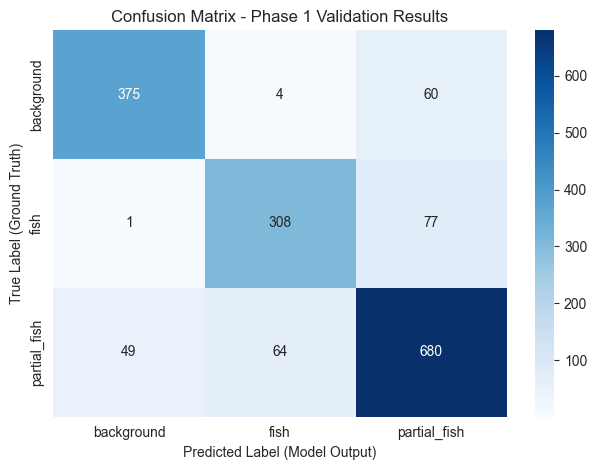

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

# 1. Set the model to evaluation mode (turns off dropout, batchnorm, etc.)
model.eval()

all_preds = []
all_labels = []

print("Extracting predictions from the validation set...")

# 2. Iterate through the validation set without tracking gradients (saves memory)
with torch.no_grad():
    for inputs, labels in val_loader:
        # Move tensors to the active device (GPU or CPU)
        inputs = inputs.to(device)

        # Forward pass: compute model output
        outputs = model(inputs)

        # Get the index of the max log-probability (the predicted class)
        _, preds = torch.max(outputs, 1)

        # Move predictions and labels back to CPU and convert to numpy lists
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Extract the class names from your dataset
# Expected output: ['background', 'fish', 'partial_fish']
class_names = train_dataset.classes

# 4. Generate the raw confusion matrix matrix using scikit-learn
cm = confusion_matrix(all_labels, all_preds)

# 5. Plot the confusion matrix using Seaborn's heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

# Add descriptive labels for clarity in your thesis/report
plt.ylabel('True Label (Ground Truth)')
plt.xlabel('Predicted Label (Model Output)')
plt.title('Confusion Matrix - Phase 1 Validation Results')
plt.tight_layout()

# 6. Save the final figure locally as an image file
plt.savefig('val_confusion_matrix_phase1.png')
print("Confusion matrix successfully generated and saved as 'val_confusion_matrix_phase1.png'")

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import copy

print("--- Starting Phase 2: Selective Unfreezing & Fine-Tuning ---")

# 1. Unfreeze the final convolutional block (Stage 4) of ConvNeXt Tiny
# In torchvision, Stage 4 is located at index 7 of the features sequential block
for param in model.features[7].parameters():
    param.requires_grad = True

# 2. Double-check and ensure the classifier head remains unfrozen
for param in model.classifier.parameters():
    param.requires_grad = True

# 3. Re-collect all active parameters that are now trainable
trainable_parameters_phase2 = [p for p in model.parameters() if p.requires_grad]

# 4. CRITICAL STEP: Reconfigure the optimizer with a drastically lower learning rate (1e-5)
# This prevents Catastrophic Forgetting and allows meticulous fine-tuning
optimizer = optim.AdamW(trainable_parameters_phase2, lr=1e-5, weight_decay=1e-2)

# Configuration for Phase 2 loop
NUM_EPOCHS_PHASE2 = 15
# We reset the best accuracy tracker for this phase to find the absolute best local weights
best_val_acc_phase2 = 0.0
best_model_wts_phase2 = copy.deepcopy(model.state_dict())

start_time_phase2 = time.time()

for epoch in range(NUM_EPOCHS_PHASE2):
    print(f"\nPhase 2 - Epoch {epoch+1}/{NUM_EPOCHS_PHASE2}")
    print("-" * 10)

    # === TRAINING PHASE ===
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step() # Updates both classifier and Stage 4 weights with lr=1e-5

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")

    # === VALIDATION PHASE ===
    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Save the absolute best weights achieved during Phase 2
    if epoch_val_acc > best_val_acc_phase2:
        best_val_acc_phase2 = epoch_val_acc
        best_model_wts_phase2 = copy.deepcopy(model.state_dict())

time_elapsed_phase2 = time.time() - start_time_phase2
print(f"\nPhase 2 training complete in {time_elapsed_phase2 // 60:.0f}m {time_elapsed_phase2 % 60:.0f}s")
print(f"Best Phase 2 Validation Accuracy: {best_val_acc_phase2:.4f}")

# Load the absolute best weights before concluding the script
model.load_state_dict(best_model_wts_phase2)

--- Starting Phase 2: Selective Unfreezing & Fine-Tuning ---

Phase 2 - Epoch 1/15
----------
Train Loss: 0.3344 | Train Acc: 0.8698
Val Loss: 0.3581 | Val Acc: 0.8418

Phase 2 - Epoch 2/15
----------
Train Loss: 0.3179 | Train Acc: 0.8758
Val Loss: 0.3534 | Val Acc: 0.8424

Phase 2 - Epoch 3/15
----------
Train Loss: 0.3022 | Train Acc: 0.8762
Val Loss: 0.3560 | Val Acc: 0.8473

Phase 2 - Epoch 4/15
----------
Train Loss: 0.2876 | Train Acc: 0.8796
Val Loss: 0.3520 | Val Acc: 0.8473

Phase 2 - Epoch 5/15
----------
Train Loss: 0.2727 | Train Acc: 0.8951
Val Loss: 0.3474 | Val Acc: 0.8486

Phase 2 - Epoch 6/15
----------
Train Loss: 0.2580 | Train Acc: 0.8981
Val Loss: 0.3449 | Val Acc: 0.8523

Phase 2 - Epoch 7/15
----------
Train Loss: 0.2491 | Train Acc: 0.9015
Val Loss: 0.3464 | Val Acc: 0.8504

Phase 2 - Epoch 8/15
----------
Train Loss: 0.2313 | Train Acc: 0.9071
Val Loss: 0.3423 | Val Acc: 0.8511

Phase 2 - Epoch 9/15
----------
Train Loss: 0.2190 | Train Acc: 0.9169
Val Loss: 0

<All keys matched successfully>

Extracting final predictions from the validation set (Post Phase 2)...
Final confusion matrix successfully generated and saved as 'val_confusion_matrix_phase2.png'


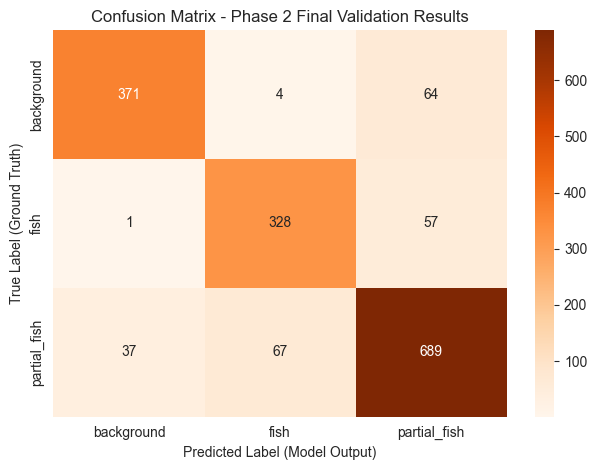

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

# 1. Set the model to evaluation mode (essential after training Phase 2)
model.eval()

all_preds_phase2 = []
all_labels_phase2 = []

print("Extracting final predictions from the validation set (Post Phase 2)...")

# 2. Iterate through the validation set without tracking gradients
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        # Forward pass: compute final model output
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Collect predictions and labels back to CPU
        all_preds_phase2.extend(preds.cpu().numpy())
        all_labels_phase2.extend(labels.cpu().numpy())

# 3. Extract the class names from your dataset
class_names = train_dataset.classes

# 4. Generate the final raw confusion matrix
cm_phase2 = confusion_matrix(all_labels_phase2, all_preds_phase2)

# 5. Plot the final confusion matrix using Seaborn's heatmap
sns.heatmap(cm_phase2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)

# Add descriptive labels for clarity in your thesis
plt.ylabel('True Label (Ground Truth)')
plt.xlabel('Predicted Label (Model Output)')
plt.title('Confusion Matrix - Phase 2 Final Validation Results')
plt.tight_layout()

# 6. Save the final figure locally
plt.savefig('val_confusion_matrix_phase2.png')
print("Final confusion matrix successfully generated and saved as 'val_confusion_matrix_phase2.png'")